In [2]:
# MNIST CNN + SHAP

This notebook trains a CNN on MNIST, evaluates its accuracy, and reproduces SHAP-style explanations for input pixels and first-layer convolutional features.

SyntaxError: invalid syntax (1061465965.py, line 3)

In [1]:
%pip install torch torchvision scikit-learn shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


100%|██████████| 9.91M/9.91M [00:03<00:00, 2.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 70.6kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 817kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.17MB/s]


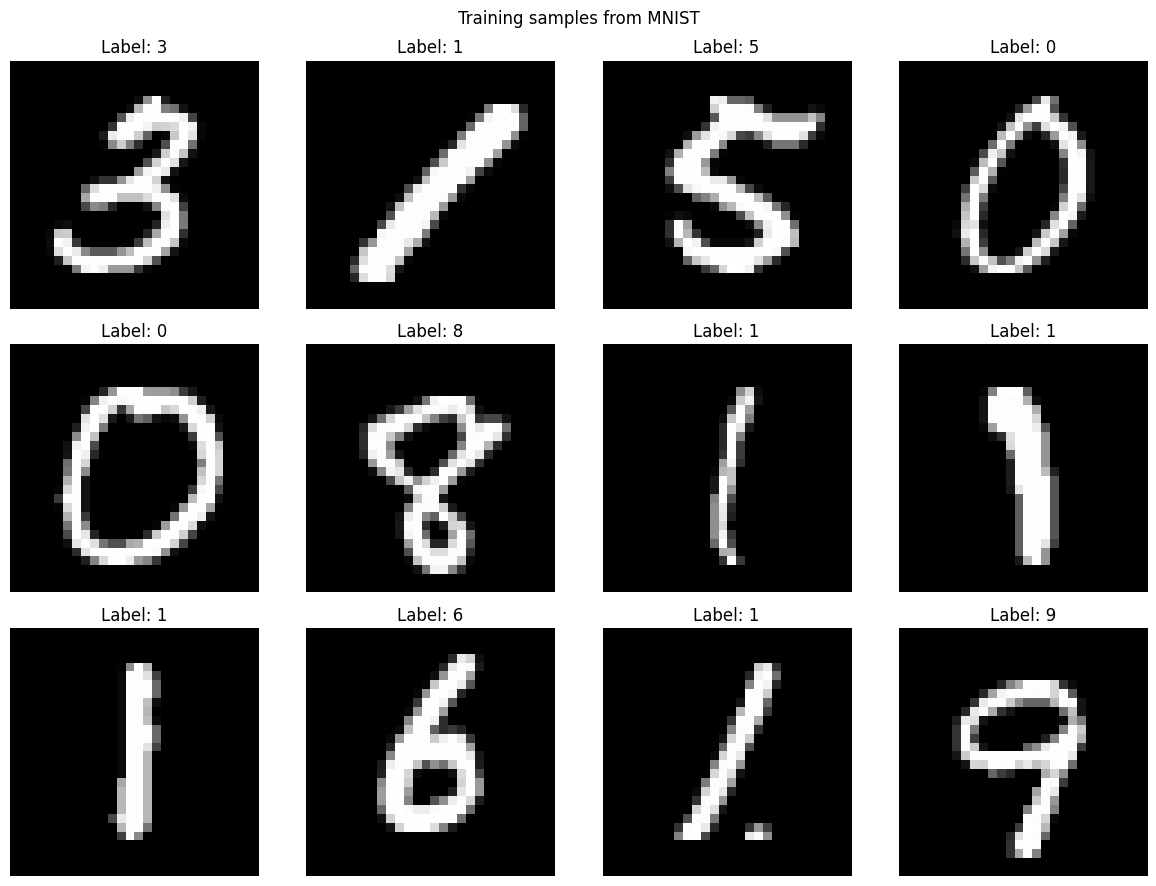

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Epoch 01/4 | train loss 0.1877 acc 0.9446 | val loss 0.0796 acc 0.9784
Epoch 02/4 | train loss 0.0484 acc 0.9853 | val loss 0.0497 acc 0.9854
Epoch 03/4 | train loss 0.0336 acc 0.9895 | val loss 0.0435 acc 0.9880
Epoch 04/4 | train loss 0.0250 acc 0.9921 | val loss 0.0396 acc 0.9888
Best validation accuracy: 0.9888
Test loss: 0.0277
Test accuracy: 0.9912

Classification report on the test set:

              precision    recall  f1-score   support

           0     0.9869    0.9980    0.9924       980
           1     0.9965    0.9965    0.9965      1135
           2     0.9827    0.9932    0.9880      1032
           

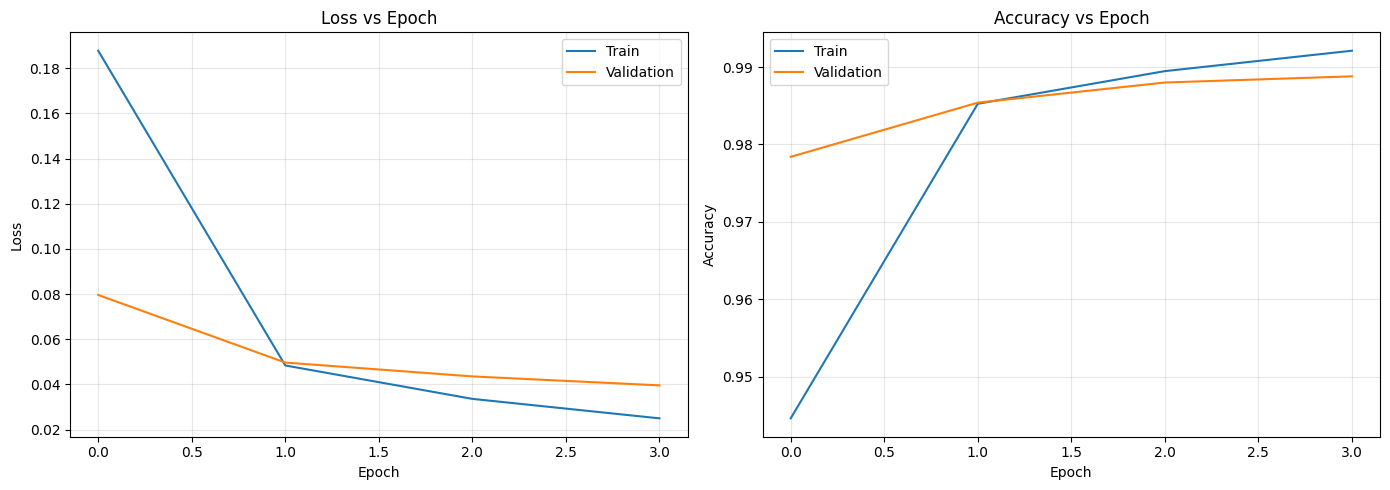

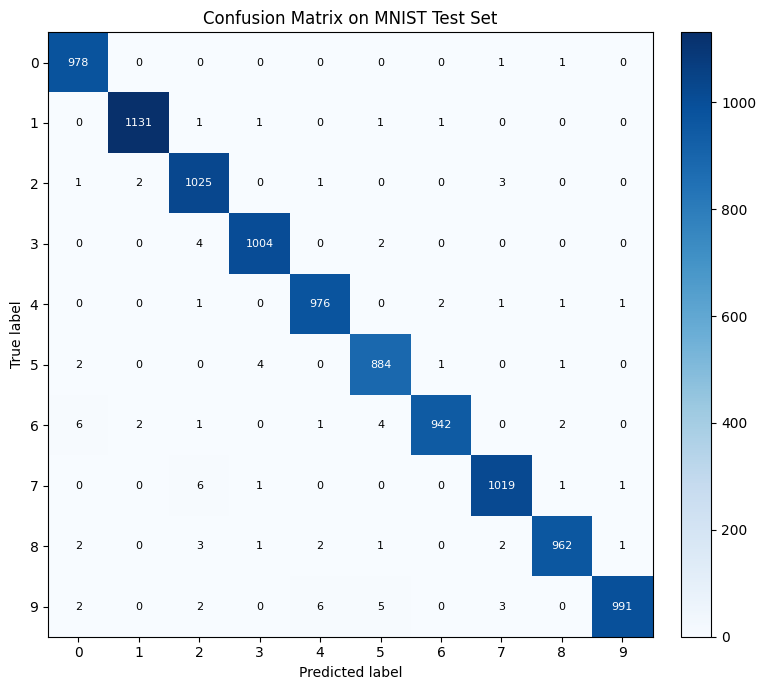

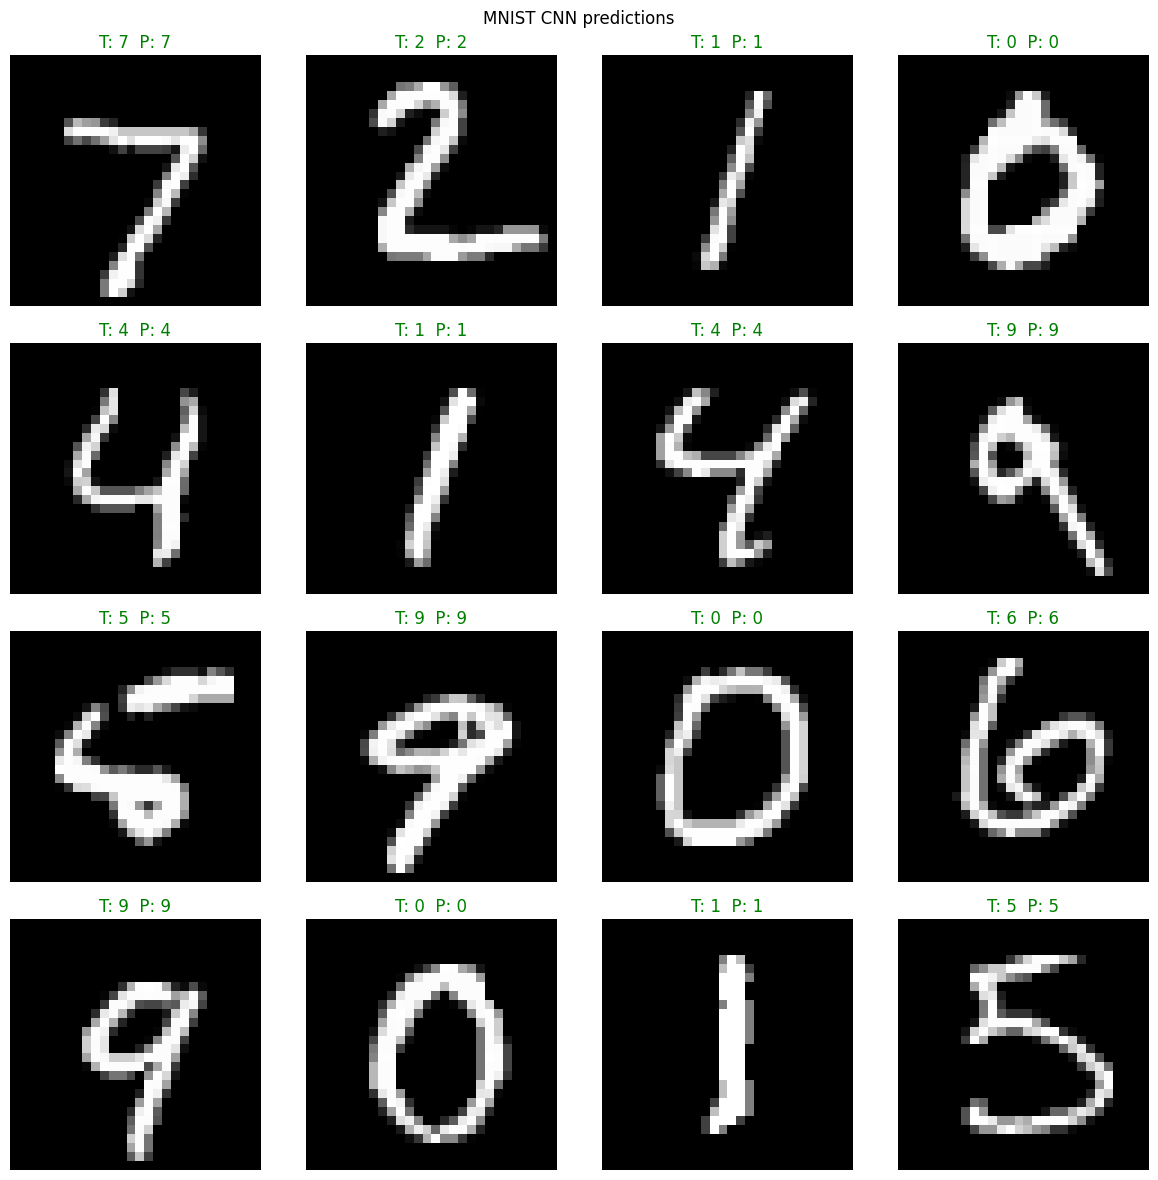

Input SHAP array shape: (6, 1, 28, 28, 10)


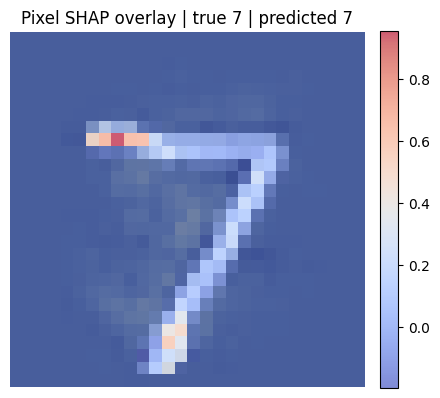

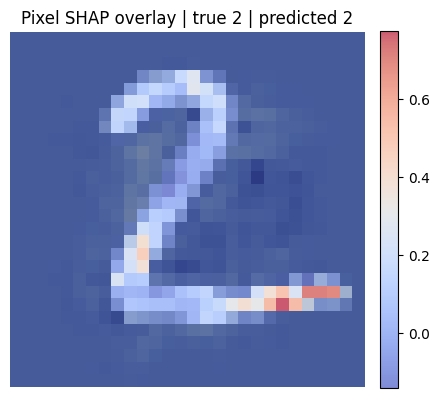

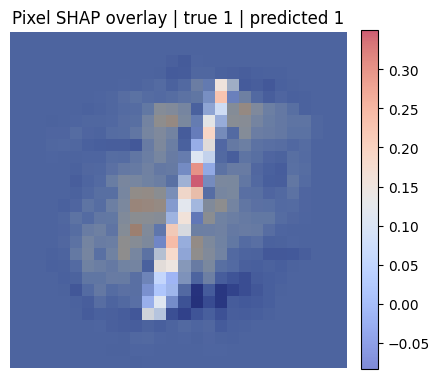

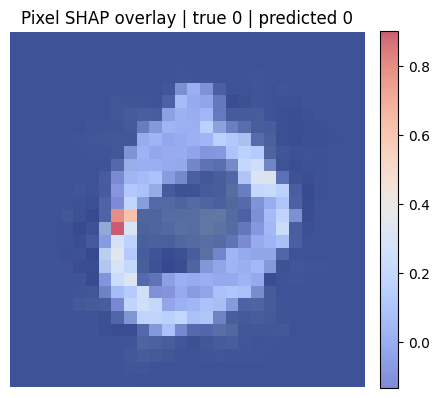

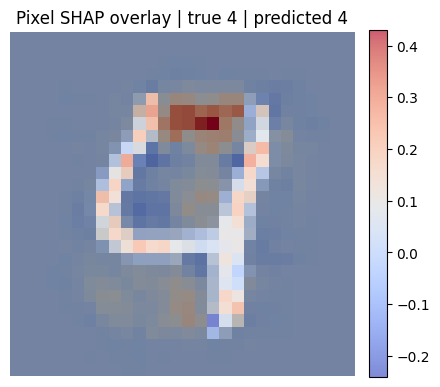

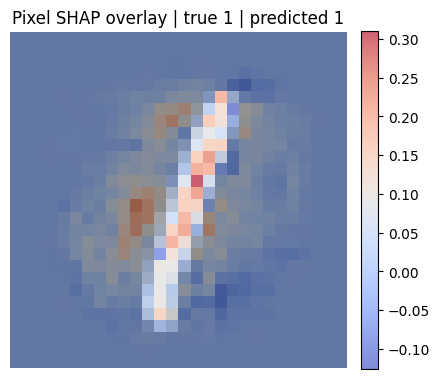

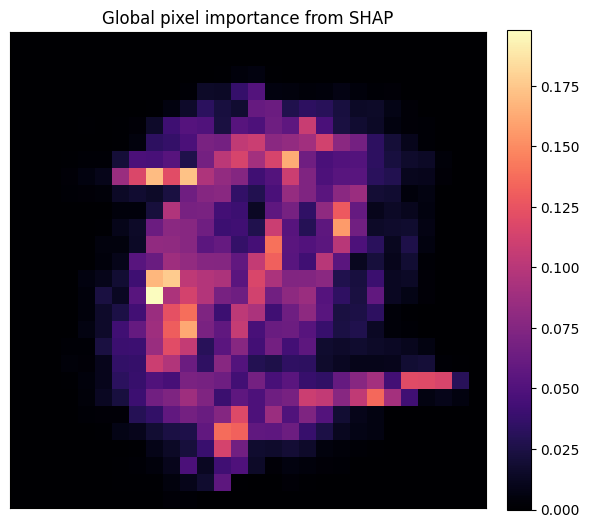

Top pixel locations by mean absolute SHAP:
01. pixel (15, 8) -> 0.197920
02. pixel (14, 9) -> 0.176782
03. pixel (8, 10) -> 0.172612
04. pixel (8, 8) -> 0.170249
05. pixel (14, 8) -> 0.168255
06. pixel (7, 16) -> 0.163516
07. pixel (17, 10) -> 0.162185
08. pixel (11, 19) -> 0.156351
09. pixel (12, 15) -> 0.139188
10. pixel (16, 10) -> 0.137632
11. pixel (23, 12) -> 0.136846
12. pixel (21, 21) -> 0.135647
13. pixel (23, 13) -> 0.132718
14. pixel (13, 15) -> 0.132141
15. pixel (17, 9) -> 0.130532
Kernel SHAP array shape: (6, 32, 28, 28, 10)


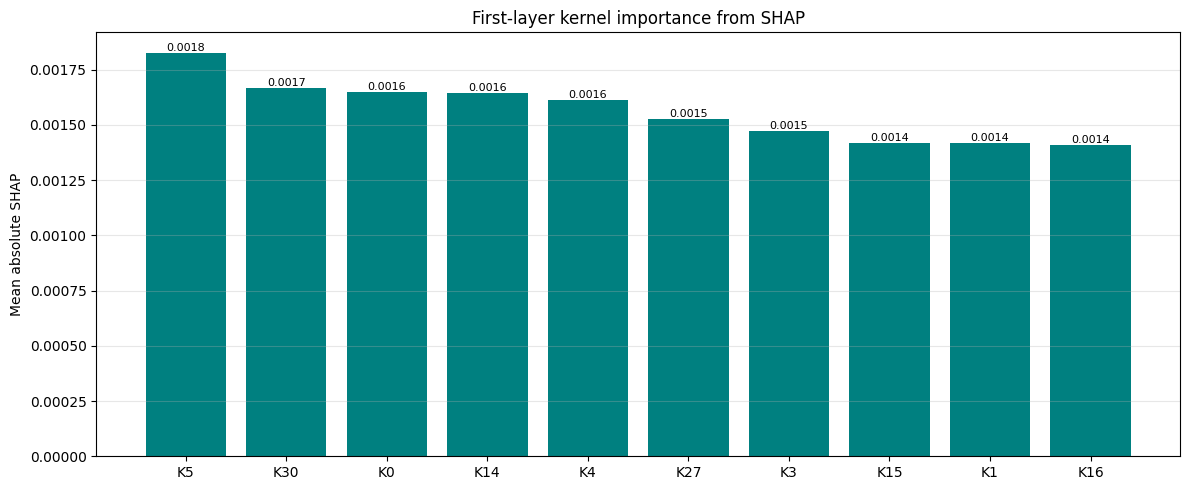

Top kernels by mean absolute SHAP:
Kernel 05: 0.001828
Kernel 30: 0.001667
Kernel 00: 0.001648
Kernel 14: 0.001646
Kernel 04: 0.001613
Kernel 27: 0.001529
Kernel 03: 0.001470
Kernel 15: 0.001420
Kernel 01: 0.001416
Kernel 16: 0.001407


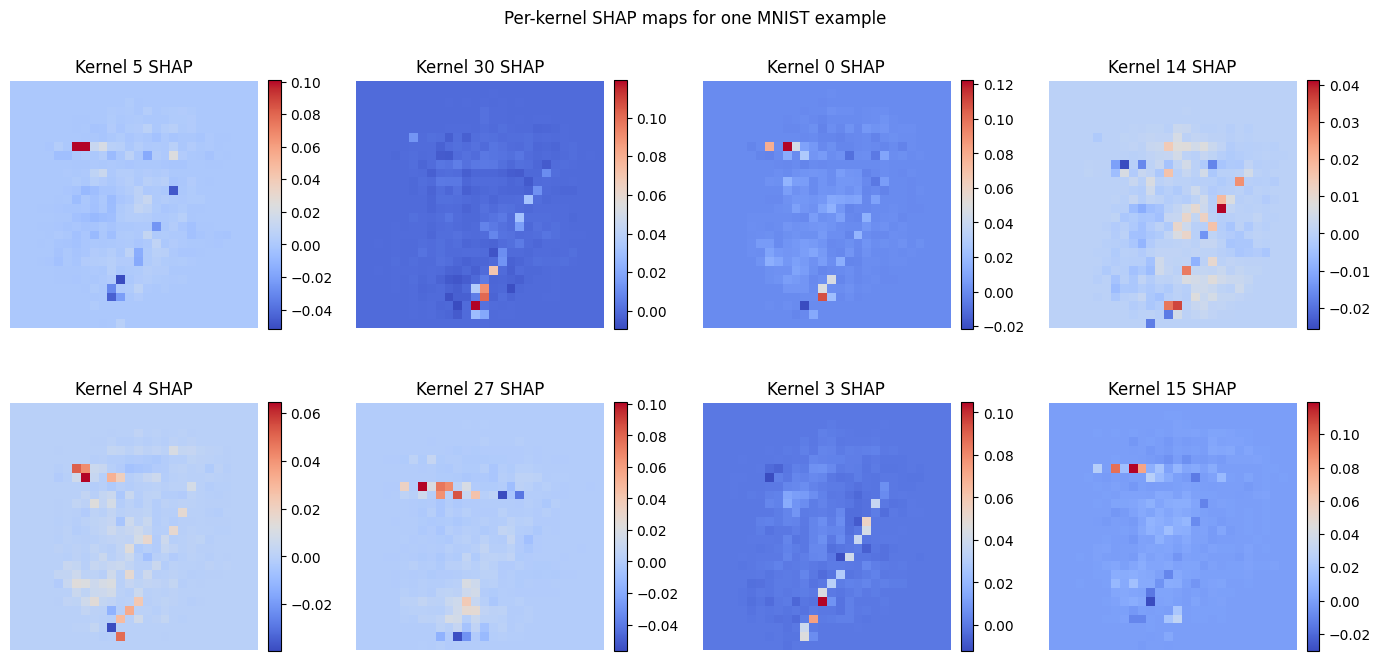

In [2]:
import copy
import random
from pathlib import Path
import ssl

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Fix SSL certificate issue for MNIST download
ssl._create_default_https_context = ssl._create_unverified_context

try:
    import shap
except ImportError as exc:
    raise ImportError("Please install shap first: pip install shap") from exc

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Data loading and quick samples
# -----------------------------

mean = 0.1307
std = 0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),
])

data_root = Path("./data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_size = 55000
val_size = len(full_train_dataset) - train_size
split_generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=split_generator)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)


def denormalize(batch: torch.Tensor) -> torch.Tensor:
    mean_tensor = torch.tensor((mean,), device=batch.device).view(1, 1, 1, 1)
    std_tensor = torch.tensor((std,), device=batch.device).view(1, 1, 1, 1)
    return batch * std_tensor + mean_tensor


def show_mnist_grid(loader, n=16, title="MNIST samples"):
    images, labels = next(iter(loader))
    images = denormalize(images[:n]).cpu()
    labels = labels[:n].cpu()
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n:]:
        ax.axis("off")
    for ax, image, label in zip(axes, images, labels):
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(f"Label: {int(label)}")
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


show_mnist_grid(train_loader, n=12, title="Training samples from MNIST")

# -----------------------------
# CNN model and training loops
# -----------------------------

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward_features(self, x):
        conv1_act = F.relu(self.conv1(x))
        pooled1 = self.pool(conv1_act)
        conv2_act = F.relu(self.conv2(pooled1))
        pooled2 = self.pool(conv2_act)
        flat = torch.flatten(pooled2, start_dim=1)
        hidden = F.relu(self.fc1(flat))
        logits = self.fc2(hidden)
        return logits, conv1_act, conv2_act, hidden

    def forward(self, x):
        return self.forward_features(x)[0]


model = MNISTCNN().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 4
best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
train_losses = []
val_losses = []
train_accs = []
val_accs = []


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        if training:
            loss.backward()
            optimizer.step()

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_seen += batch_size
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_probs.append(probs.detach().cpu())

    mean_loss = total_loss / total_seen
    mean_acc = total_correct / total_seen
    return mean_loss, mean_acc, torch.cat(all_preds), torch.cat(all_labels), torch.cat(all_probs)


for epoch in range(1, epochs + 1):
    train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc, _, _, _ = run_epoch(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

model.load_state_dict(best_state)
model.eval()

test_loss, test_acc, test_preds, test_labels, test_probs = run_epoch(model, test_loader)
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print("\nClassification report on the test set:\n")
print(classification_report(test_labels.numpy(), test_preds.numpy(), digits=4))

# -----------------------------
# CNN graphs: learning curves, confusion matrix, predictions
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Validation")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label="Train")
axes[1].plot(val_accs, label="Validation")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy())
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix on MNIST Test Set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        value = cm[i, j]
        ax.text(j, i, str(value), ha="center", va="center", color="black" if value < cm.max() / 2 else "white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:16].to(device)
sample_labels = sample_labels[:16].cpu()
with torch.no_grad():
    sample_logits = model(sample_images)
sample_predictions = torch.argmax(sample_logits, dim=1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.reshape(-1)
for idx, ax in enumerate(axes):
    image = denormalize(sample_images[idx:idx + 1]).cpu()[0, 0]
    ax.imshow(image, cmap="gray")
    true_label = int(sample_labels[idx])
    pred_label = int(sample_predictions[idx])
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T: {true_label}  P: {pred_label}", color=color)
    ax.axis("off")
fig.suptitle("MNIST CNN predictions")
fig.tight_layout()
plt.show()

# -----------------------------
# SHAP on input pixels
# -----------------------------

model.eval()
background_images, _ = next(iter(train_loader))
background_images = background_images[:64].to(device)
explain_images, explain_labels = next(iter(test_loader))
explain_images = explain_images[:6].to(device)
explain_labels = explain_labels[:6].cpu()

input_explainer = shap.GradientExplainer(model, background_images)
input_shap_values = input_explainer.shap_values(explain_images)

with torch.no_grad():
    explain_logits = model(explain_images)
explain_predictions = torch.argmax(explain_logits, dim=1).cpu().numpy()

if isinstance(input_shap_values, list):
    print("Input SHAP outputs:", len(input_shap_values), "classes")
    print("Input SHAP sample shape:", np.asarray(input_shap_values[0]).shape)
else:
    print("Input SHAP array shape:", np.asarray(input_shap_values).shape)


def get_class_map(shap_values, sample_index, class_index):
    if isinstance(shap_values, list):
        sample_map = shap_values[class_index][sample_index]
    else:
        shap_array = np.asarray(shap_values)
        if shap_array.ndim >= 5 and shap_array.shape[1] == 10:
            sample_map = shap_array[sample_index, class_index]
        elif shap_array.ndim >= 4 and shap_array.shape[-1] == 10:
            sample_map = shap_array[sample_index, ..., class_index]
        else:
            sample_map = shap_array[sample_index]
    sample_map = np.asarray(sample_map)
    if sample_map.ndim == 3 and sample_map.shape[0] == 1:
        sample_map = sample_map[0]
    if sample_map.ndim == 3 and sample_map.shape[-1] == 1:
        sample_map = sample_map[..., 0]
    return sample_map


def plot_pixel_shap(image_tensor, shap_map, title):
    image = denormalize(image_tensor.unsqueeze(0)).cpu().numpy()[0, 0]
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(image, cmap="gray")
    overlay = ax.imshow(shap_map, cmap="coolwarm", alpha=0.65)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(overlay, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


selected_pixel_maps = []
for idx in range(len(explain_images)):
    pred_class = int(explain_predictions[idx])
    selected_map = get_class_map(input_shap_values, idx, pred_class)
    selected_pixel_maps.append(selected_map)
    plot_pixel_shap(
        explain_images[idx],
        selected_map,
        f"Pixel SHAP overlay | true {int(explain_labels[idx])} | predicted {pred_class}",
    )

selected_pixel_maps = np.stack(selected_pixel_maps)
mean_abs_pixel_importance = np.mean(np.abs(selected_pixel_maps), axis=0)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(mean_abs_pixel_importance, cmap="magma")
ax.set_title("Global pixel importance from SHAP")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

flat_pixel_importance = mean_abs_pixel_importance.ravel()
top_pixel_indices = np.argsort(flat_pixel_importance)[::-1][:15]
print("Top pixel locations by mean absolute SHAP:")
for rank, flat_index in enumerate(top_pixel_indices, start=1):
    row, col = divmod(int(flat_index), 28)
    print(f"{rank:02d}. pixel ({row}, {col}) -> {flat_pixel_importance[flat_index]:.6f}")

# -----------------------------
# SHAP on first-layer kernels / feature maps
# -----------------------------

class TailFromConv1(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.pool = base_model.pool
        self.conv2 = base_model.conv2
        self.fc1 = base_model.fc1
        self.fc2 = base_model.fc2

    def forward(self, conv1_activations):
        x = self.pool(conv1_activations)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


tail_model = TailFromConv1(model).to(device)

with torch.no_grad():
    _, background_conv1, _, _ = model.forward_features(background_images)
    _, explain_conv1, _, _ = model.forward_features(explain_images)

kernel_explainer = shap.GradientExplainer(tail_model, background_conv1)
kernel_shap_values = kernel_explainer.shap_values(explain_conv1)

if isinstance(kernel_shap_values, list):
    print("Kernel SHAP outputs:", len(kernel_shap_values), "classes")
    print("Kernel SHAP sample shape:", np.asarray(kernel_shap_values[0]).shape)
else:
    print("Kernel SHAP array shape:", np.asarray(kernel_shap_values).shape)

selected_kernel_maps = []
for idx in range(len(explain_images)):
    pred_class = int(explain_predictions[idx])
    selected_kernel_maps.append(get_class_map(kernel_shap_values, idx, pred_class))
selected_kernel_maps = np.stack(selected_kernel_maps)

channel_importance = np.mean(np.abs(selected_kernel_maps), axis=(0, 2, 3))
top_channels = np.argsort(channel_importance)[::-1][:10]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top_channels)), channel_importance[top_channels], color="teal")
ax.set_xticks(range(len(top_channels)))
ax.set_xticklabels([f"K{channel}" for channel in top_channels])
ax.set_ylabel("Mean absolute SHAP")
ax.set_title("First-layer kernel importance from SHAP")
ax.grid(axis="y", alpha=0.3)
for bar, channel in zip(bars, top_channels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
fig.tight_layout()
plt.show()

print("Top kernels by mean absolute SHAP:")
for channel in top_channels:
    print(f"Kernel {int(channel):02d}: {channel_importance[channel]:.6f}")

sample_kernel_map = selected_kernel_maps[0]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.reshape(-1)
for ax, channel in zip(axes, top_channels[:8]):
    im = ax.imshow(sample_kernel_map[channel], cmap="coolwarm")
    ax.set_title(f"Kernel {int(channel)} SHAP")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axes[len(top_channels[:8]):]:
    ax.axis("off")
fig.suptitle("Per-kernel SHAP maps for one MNIST example")
fig.tight_layout()
plt.show()

Digits selected for SHAP: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Predicted classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


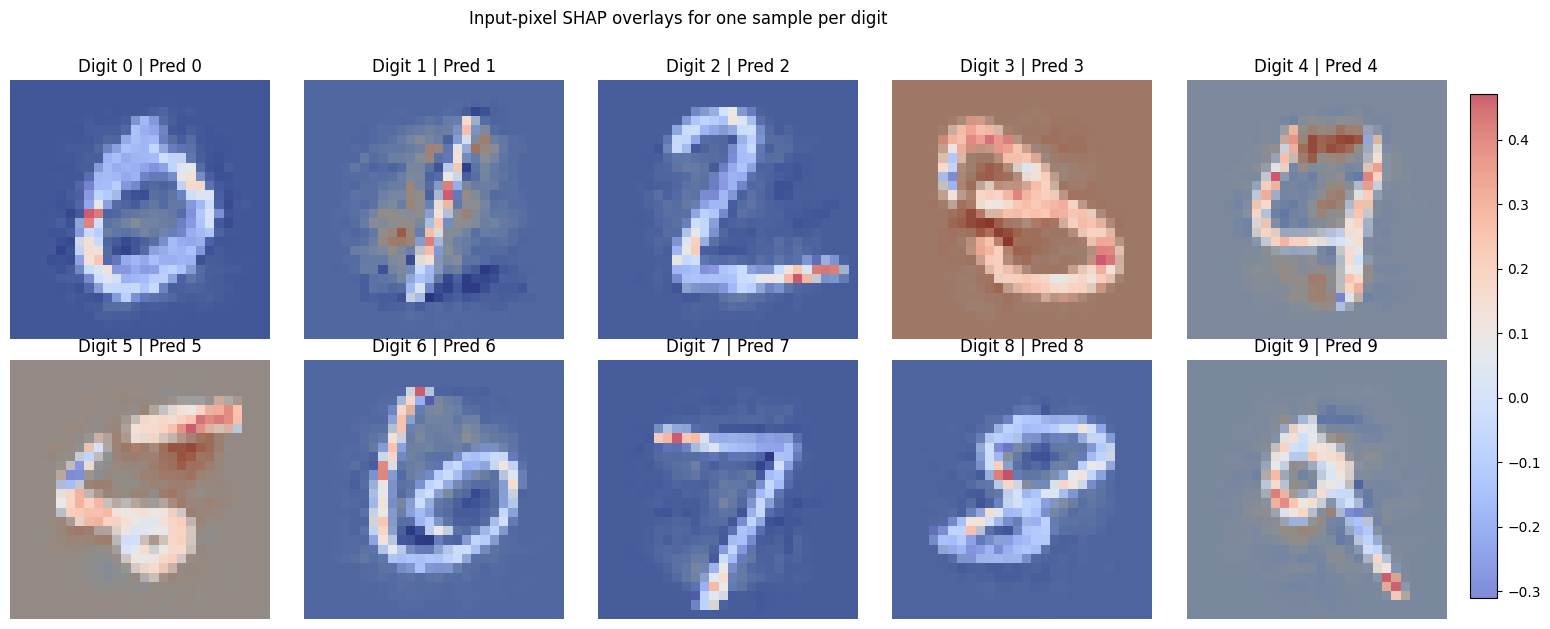

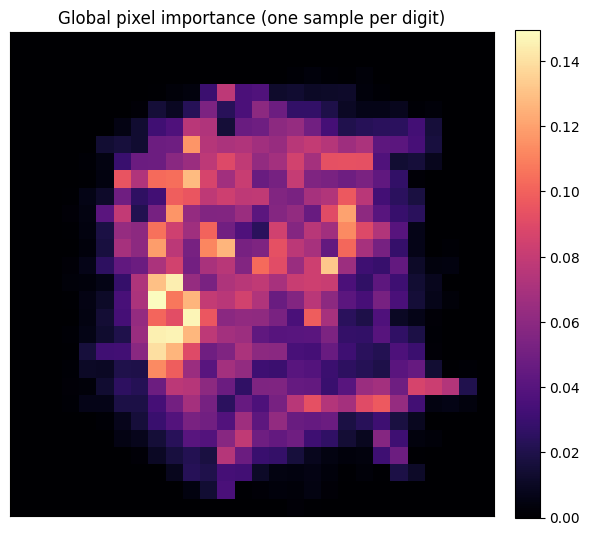

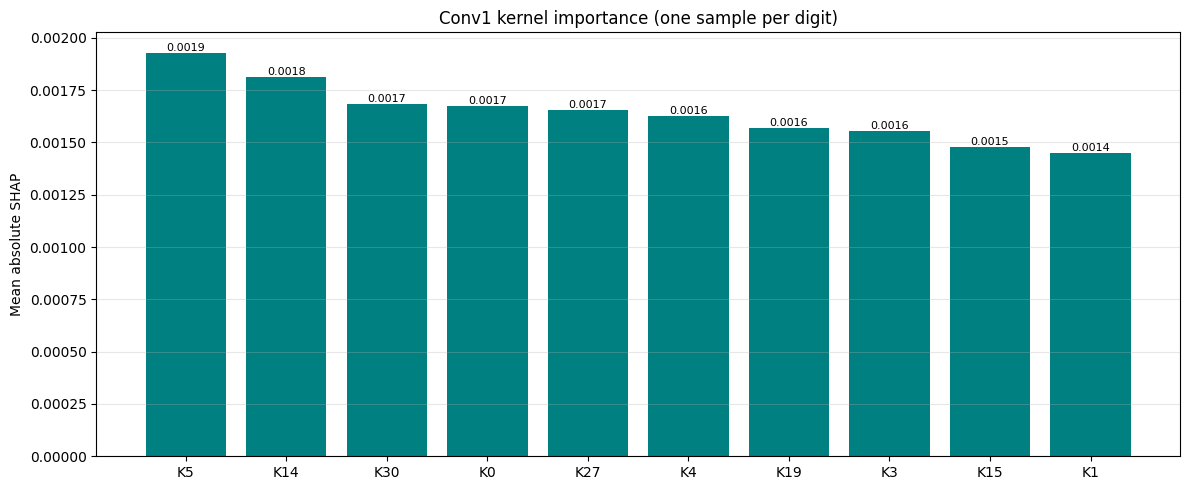

Top kernels by mean absolute SHAP (one sample per digit):
Kernel 05: 0.001930
Kernel 14: 0.001813
Kernel 30: 0.001681
Kernel 00: 0.001672
Kernel 27: 0.001656
Kernel 04: 0.001625
Kernel 19: 0.001568
Kernel 03: 0.001553
Kernel 15: 0.001479
Kernel 01: 0.001449


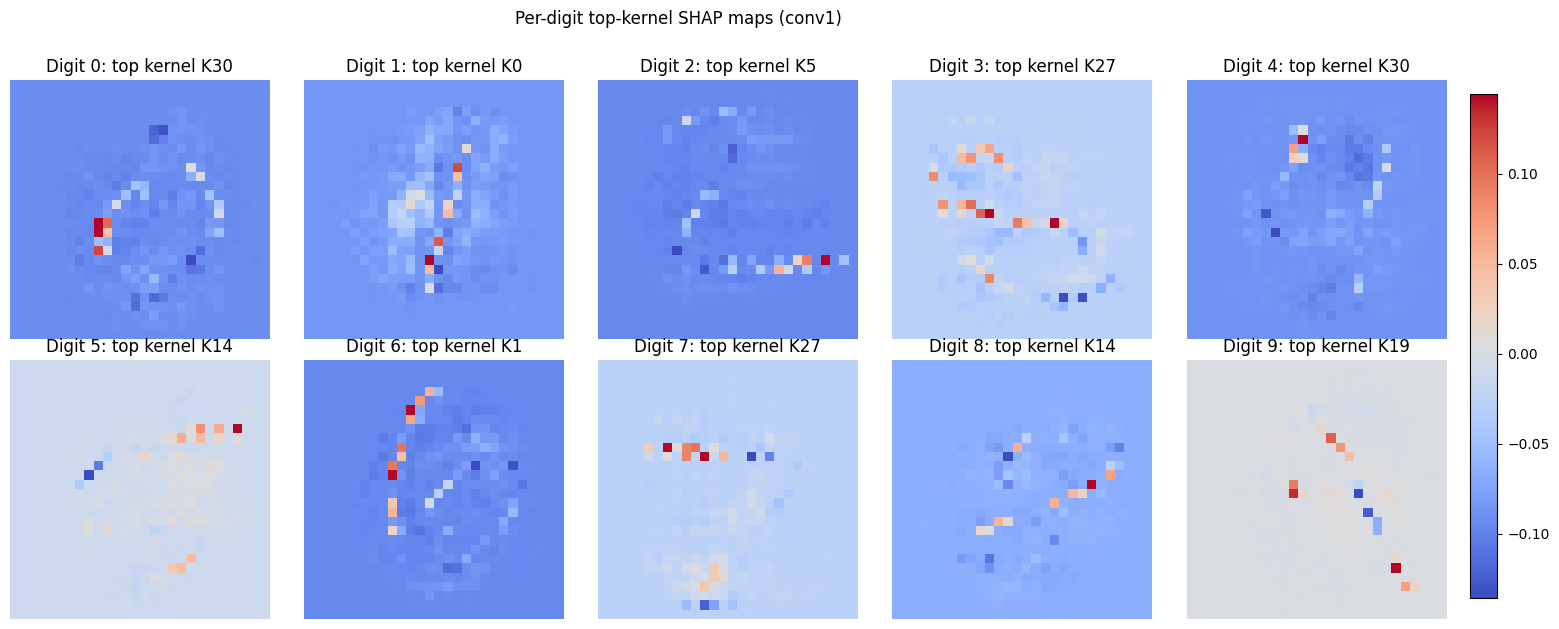

In [3]:
# ==========================================================
# SHAP rerun: exactly one image per digit (0..9)
# ==========================================================

def select_one_per_digit(loader, device, num_classes=10):
    selected = {}
    for images, labels in loader:
        for img, lab in zip(images, labels):
            lab_int = int(lab.item())
            if lab_int not in selected:
                selected[lab_int] = img.unsqueeze(0)
            if len(selected) == num_classes:
                break
        if len(selected) == num_classes:
            break

    missing = sorted(set(range(num_classes)) - set(selected.keys()))
    if missing:
        raise RuntimeError(f"Could not find samples for digits: {missing}")

    ordered_images = torch.cat([selected[d] for d in range(num_classes)], dim=0).to(device)
    ordered_labels = torch.tensor(list(range(num_classes)))
    return ordered_images, ordered_labels


# One test sample for each digit 0..9
explain_images_10, explain_labels_10 = select_one_per_digit(test_loader, device, num_classes=10)
print("Digits selected for SHAP:", explain_labels_10.tolist())

# Background for SHAP
background_images_10, _ = next(iter(train_loader))
background_images_10 = background_images_10[:64].to(device)

# ---------- Input-level SHAP ----------
input_explainer_10 = shap.GradientExplainer(model, background_images_10)
input_shap_values_10 = input_explainer_10.shap_values(explain_images_10)

with torch.no_grad():
    explain_logits_10 = model(explain_images_10)
explain_predictions_10 = torch.argmax(explain_logits_10, dim=1).cpu().numpy()

print("Predicted classes:", explain_predictions_10.tolist())

selected_pixel_maps_10 = []
for idx in range(len(explain_images_10)):
    pred_class = int(explain_predictions_10[idx])
    selected_map = get_class_map(input_shap_values_10, idx, pred_class)
    selected_pixel_maps_10.append(selected_map)

selected_pixel_maps_10 = np.stack(selected_pixel_maps_10)

# Plot all 10 input SHAP overlays (2x5)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.reshape(-1)
for i, ax in enumerate(axes):
    img = denormalize(explain_images_10[i:i+1]).cpu().numpy()[0, 0]
    shp = selected_pixel_maps_10[i]
    ax.imshow(img, cmap="gray")
    overlay = ax.imshow(shp, cmap="coolwarm", alpha=0.65)
    ax.set_title(f"Digit {int(explain_labels_10[i])} | Pred {int(explain_predictions_10[i])}")
    ax.axis("off")
fig.subplots_adjust(right=0.93, wspace=0.08, hspace=0.08)
cax = fig.add_axes([0.94, 0.14, 0.015, 0.72])
fig.colorbar(overlay, cax=cax)
fig.suptitle("Input-pixel SHAP overlays for one sample per digit", y=0.98)
plt.show()

# Global pixel importance over the 10 selected images
mean_abs_pixel_importance_10 = np.mean(np.abs(selected_pixel_maps_10), axis=0)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(mean_abs_pixel_importance_10, cmap="magma")
ax.set_title("Global pixel importance (one sample per digit)")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

# ---------- Kernel-level SHAP on conv1 feature maps ----------
with torch.no_grad():
    _, background_conv1_10, _, _ = model.forward_features(background_images_10)
    _, explain_conv1_10, _, _ = model.forward_features(explain_images_10)

tail_model_10 = TailFromConv1(model).to(device)
kernel_explainer_10 = shap.GradientExplainer(tail_model_10, background_conv1_10)
kernel_shap_values_10 = kernel_explainer_10.shap_values(explain_conv1_10)

selected_kernel_maps_10 = []
for idx in range(len(explain_images_10)):
    pred_class = int(explain_predictions_10[idx])
    selected_kernel_maps_10.append(get_class_map(kernel_shap_values_10, idx, pred_class))
selected_kernel_maps_10 = np.stack(selected_kernel_maps_10)

# Mean kernel importance across all 10 selected digits
channel_importance_10 = np.mean(np.abs(selected_kernel_maps_10), axis=(0, 2, 3))
top_channels_10 = np.argsort(channel_importance_10)[::-1][:10]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top_channels_10)), channel_importance_10[top_channels_10], color="teal")
ax.set_xticks(range(len(top_channels_10)))
ax.set_xticklabels([f"K{channel}" for channel in top_channels_10])
ax.set_ylabel("Mean absolute SHAP")
ax.set_title("Conv1 kernel importance (one sample per digit)")
ax.grid(axis="y", alpha=0.3)
for bar, channel in zip(bars, top_channels_10):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
fig.tight_layout()
plt.show()

print("Top kernels by mean absolute SHAP (one sample per digit):")
for channel in top_channels_10:
    print(f"Kernel {int(channel):02d}: {channel_importance_10[channel]:.6f}")

# For each digit, show the SHAP map of its most important conv1 kernel
per_digit_kernel_strength = np.mean(np.abs(selected_kernel_maps_10), axis=(2, 3))  # [10, 32]
per_digit_top_kernel = np.argmax(per_digit_kernel_strength, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.reshape(-1)
for i, ax in enumerate(axes):
    k = int(per_digit_top_kernel[i])
    im = ax.imshow(selected_kernel_maps_10[i, k], cmap="coolwarm")
    ax.set_title(f"Digit {int(explain_labels_10[i])}: top kernel K{k}")
    ax.axis("off")
fig.subplots_adjust(right=0.93, wspace=0.08, hspace=0.08)
cax = fig.add_axes([0.94, 0.14, 0.015, 0.72])
fig.colorbar(im, cax=cax)
fig.suptitle("Per-digit top-kernel SHAP maps (conv1)", y=0.98)
plt.show()


Balanced subset collected: 5000 samples
Samples per digit: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}
Expected total: 5000
Processed 512 / 5000 balanced samples for kernel SHAP
Processed 1024 / 5000 balanced samples for kernel SHAP
Processed 1536 / 5000 balanced samples for kernel SHAP
Processed 2048 / 5000 balanced samples for kernel SHAP
Processed 2560 / 5000 balanced samples for kernel SHAP
Processed 3072 / 5000 balanced samples for kernel SHAP
Processed 3584 / 5000 balanced samples for kernel SHAP
Processed 4096 / 5000 balanced samples for kernel SHAP
Processed 4608 / 5000 balanced samples for kernel SHAP
Processed 5000 / 5000 balanced samples for kernel SHAP


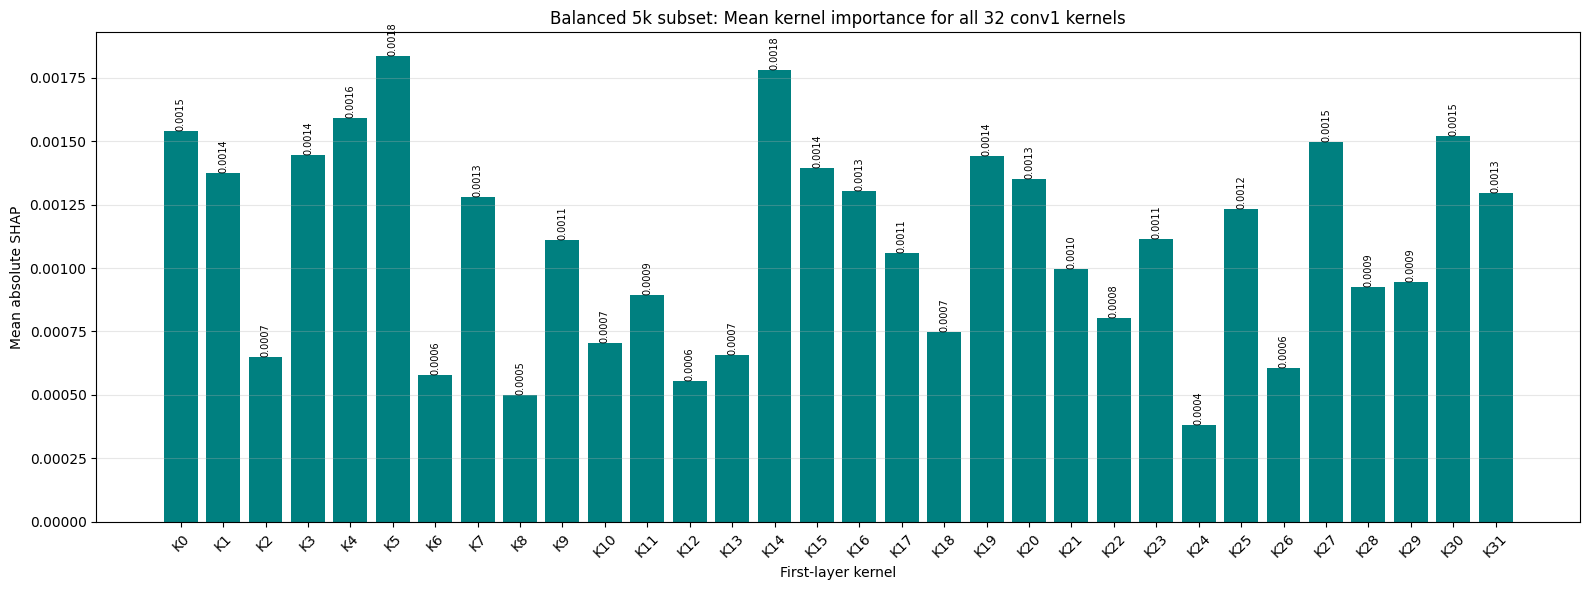

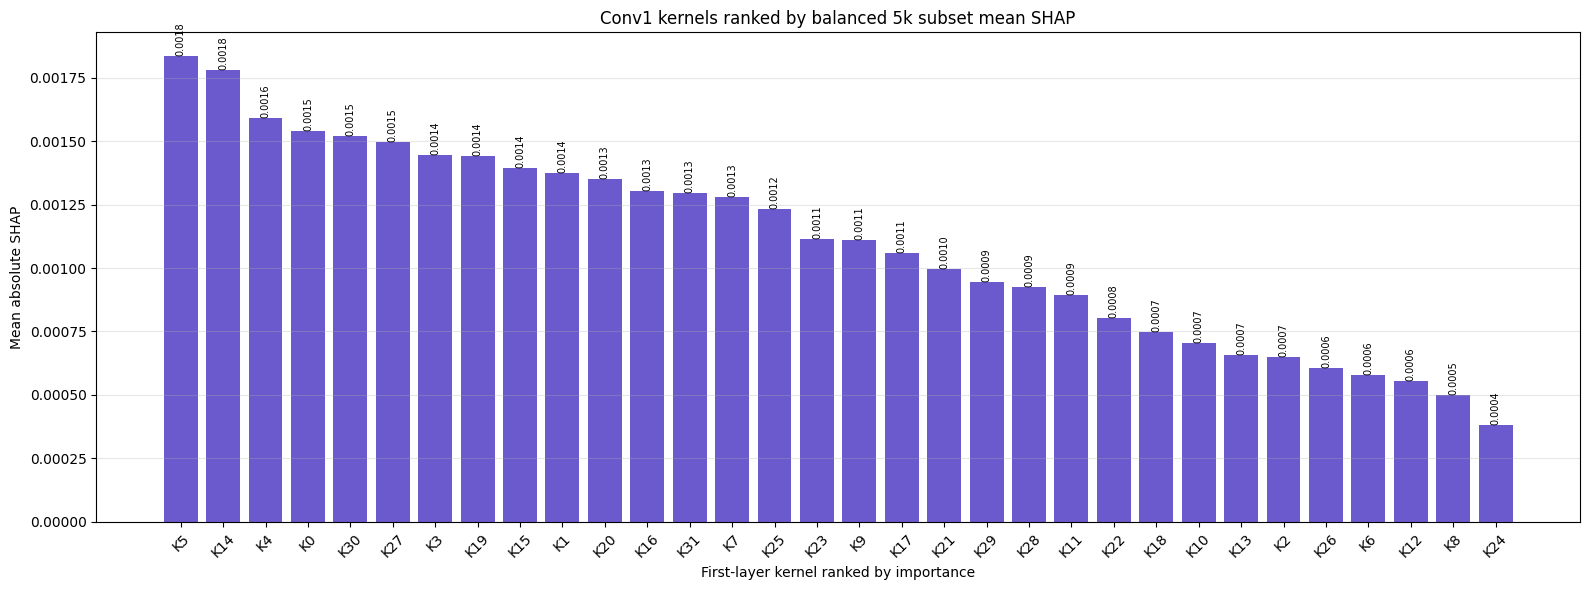


Top 10 kernels by balanced 5k subset mean absolute SHAP:
01. Kernel 05: 0.001837
02. Kernel 14: 0.001780
03. Kernel 04: 0.001592
04. Kernel 00: 0.001541
05. Kernel 30: 0.001520
06. Kernel 27: 0.001496
07. Kernel 03: 0.001446
08. Kernel 19: 0.001440
09. Kernel 15: 0.001393
10. Kernel 01: 0.001375

Bottom 10 kernels (least important):
01. Kernel 22: 0.000805
02. Kernel 18: 0.000746
03. Kernel 10: 0.000705
04. Kernel 13: 0.000656
05. Kernel 02: 0.000651
06. Kernel 26: 0.000608
07. Kernel 06: 0.000579
08. Kernel 12: 0.000554
09. Kernel 08: 0.000500
10. Kernel 24: 0.000382


In [4]:
# ==========================================================
# Dataset-wide kernel SHAP over a balanced 5k subset
# ==========================================================

# Use a balanced 5k subset (500 samples per digit, 0-9) to avoid bias
# while keeping computation time reasonable.

# Collect balanced subset: 500 samples per digit
balanced_images = []
balanced_labels = []
samples_per_digit = {i: 0 for i in range(10)}
TARGET_PER_DIGIT = 500
TOTAL_TARGET = 5000

for images, labels in test_loader:
    for img, lab in zip(images, labels):
        lab_int = int(lab.item())
        if samples_per_digit[lab_int] < TARGET_PER_DIGIT:
            balanced_images.append(img)
            balanced_labels.append(lab)
            samples_per_digit[lab_int] += 1
    
    if sum(samples_per_digit.values()) >= TOTAL_TARGET:
        break

balanced_images = torch.stack(balanced_images).to(device)
balanced_labels = torch.stack(balanced_labels)

print(f"Balanced subset collected: {len(balanced_labels)} samples")
print(f"Samples per digit: {samples_per_digit}")
print(f"Expected total: {TOTAL_TARGET}")

# Background for SHAP
background_images_full, _ = next(iter(train_loader))
background_images_full = background_images_full[:64].to(device)
with torch.no_grad():
    _, background_conv1_full, _, _ = model.forward_features(background_images_full)

full_kernel_tail_model = TailFromConv1(model).to(device)
full_kernel_explainer = shap.GradientExplainer(full_kernel_tail_model, background_conv1_full)

kernel_sum = np.zeros(32, dtype=np.float64)
kernel_sample_count = 0

# Process balanced subset in batches
batch_size = 256
num_batches = int(np.ceil(len(balanced_images) / batch_size))

for batch_index in range(num_batches):
    start_idx = batch_index * batch_size
    end_idx = min(start_idx + batch_size, len(balanced_images))
    
    batch_images = balanced_images[start_idx:end_idx]
    batch_labels_subset = balanced_labels[start_idx:end_idx]
    
    with torch.no_grad():
        logits, conv1_activations, _, _ = model.forward_features(batch_images)
        predictions = torch.argmax(logits, dim=1).cpu().numpy()

    kernel_shap_values_batch = full_kernel_explainer.shap_values(conv1_activations)
    batch_size_actual = batch_images.size(0)

    for sample_index in range(batch_size_actual):
        predicted_class = int(predictions[sample_index])
        shap_map = get_class_map(kernel_shap_values_batch, sample_index, predicted_class)
        kernel_sum += np.mean(np.abs(shap_map), axis=(1, 2))
        kernel_sample_count += 1

    if (batch_index + 1) % 2 == 0:
        print(f"Processed {kernel_sample_count} / {len(balanced_labels)} balanced samples for kernel SHAP")

mean_kernel_importance = kernel_sum / kernel_sample_count
kernel_order = np.argsort(mean_kernel_importance)[::-1]

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(range(32), mean_kernel_importance, color="teal")
ax.set_xticks(range(32))
ax.set_xticklabels([f"K{i}" for i in range(32)], rotation=45)
ax.set_xlabel("First-layer kernel")
ax.set_ylabel("Mean absolute SHAP")
ax.set_title("Balanced 5k subset: Mean kernel importance for all 32 conv1 kernels")
ax.grid(axis="y", alpha=0.3)
for bar, value in zip(bars, mean_kernel_importance):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
ordered_values = mean_kernel_importance[kernel_order]
ordered_labels = [f"K{i}" for i in kernel_order]
bars = ax.bar(range(32), ordered_values, color="slateblue")
ax.set_xticks(range(32))
ax.set_xticklabels(ordered_labels, rotation=45)
ax.set_xlabel("First-layer kernel ranked by importance")
ax.set_ylabel("Mean absolute SHAP")
ax.set_title("Conv1 kernels ranked by balanced 5k subset mean SHAP")
ax.grid(axis="y", alpha=0.3)
for bar, value in zip(bars, ordered_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )
fig.tight_layout()
plt.show()

print("\nTop 10 kernels by balanced 5k subset mean absolute SHAP:")
for rank, kernel_index in enumerate(kernel_order[:10], start=1):
    print(f"{rank:02d}. Kernel {kernel_index:02d}: {mean_kernel_importance[kernel_index]:.6f}")

print("\nBottom 10 kernels (least important):")
for rank, kernel_index in enumerate(kernel_order[-10:], start=1):
    print(f"{rank:02d}. Kernel {kernel_index:02d}: {mean_kernel_importance[kernel_index]:.6f}")


In [6]:
# ==========================================================
# Kernel Pruning and Evaluation
# ==========================================================

# Identify the bottom 10 kernels to prune from the previous analysis
kernels_to_prune = kernel_order[-10:]
print(f"Bottom 10 kernels identified for pruning: {sorted(kernels_to_prune)}")

# Keep the top 22 kernels - convert to list to avoid negative stride issues
kernels_to_keep = kernel_order[:-10].copy().tolist()

# Create a new model with a pruned conv1 layer
class PrunedMNISTCNN(nn.Module):
    def __init__(self, original_model, kernels_to_keep):
        super().__init__()
        
        # Original layers
        original_conv1 = original_model.conv1
        original_conv2 = original_model.conv2
        
        # Convert to tensor for indexing if it's a list
        if isinstance(kernels_to_keep, list):
            kernels_to_keep = torch.tensor(kernels_to_keep)
        
        # New conv1 with 22 output channels
        self.conv1 = nn.Conv2d(1, 22, kernel_size=3, padding=1)
        
        # New conv2 with 22 input channels
        self.conv2 = nn.Conv2d(22, 64, kernel_size=3, padding=1)
        
        # Copy weights for the kept kernels
        with torch.no_grad():
            self.conv1.weight.data = original_conv1.weight.data[kernels_to_keep]
            self.conv1.bias.data = original_conv1.bias.data[kernels_to_keep]
            
            # For conv2, we need to copy weights corresponding to the kept input channels
            self.conv2.weight.data = original_conv2.weight.data[:, kernels_to_keep, :, :]
            self.conv2.bias.data = original_conv2.bias.data

        # The rest of the architecture remains the same
        self.pool = original_model.pool
        self.fc1 = original_model.fc1
        self.fc2 = original_model.fc2

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Instantiate the pruned model
pruned_model = PrunedMNISTCNN(model, kernels_to_keep).to(device)
pruned_model.eval()

print("\nEvaluating the new pruned model...")

# Evaluate the accuracy of the pruned model on the test set
pruned_loss, pruned_acc, _, _, _ = run_epoch(pruned_model, test_loader)

print("-" * 50)
print(f"Original model test accuracy: {test_acc:.4f}")
print(f"Pruned model test accuracy:   {pruned_acc:.4f}")
print("-" * 50)

accuracy_drop = test_acc - pruned_acc
print(f"Accuracy drop after pruning 10 kernels: {accuracy_drop:.4f} ({accuracy_drop/test_acc:.2%})")

Bottom 10 kernels identified for pruning: [np.int64(2), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(22), np.int64(24), np.int64(26)]

Evaluating the new pruned model...
--------------------------------------------------
Original model test accuracy: 0.9912
Pruned model test accuracy:   0.9885
--------------------------------------------------
Accuracy drop after pruning 10 kernels: 0.0027 (0.27%)
